In [1]:
import sys
from pathlib import Path

# Add src/ to sys.path regardless of where Jupyter is launched from
for _candidate in [Path().resolve().parent / "src", Path().resolve() / "src"]:
    if _candidate.exists() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        print(f"Added to sys.path: {_candidate}")
        break

Added to sys.path: C:\Users\loren\Documents\Tortues\acoustic_classifier_seaturtles\src


In [2]:
from preprocess import Preprocessing
from settings import Config
from config_species import get_settings
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pickle

In [3]:
selected_species = "gibbon" #"thyolo" # gibbon / ptw
settings = get_settings(selected_species)
config = Config(settings) # Pass settings to your config object
print("Loaded settings for:", selected_species)


Loaded settings for: gibbon


In [4]:
#to print the used preprocessing parameters
for key, value in config.preprocessing.dict().items():
    print(f"{key}: {value}")

sample_rate: 9600
lowpass_cutoff: 2000
downsample_rate: 4800
nyquist_rate: 2400
segment_duration: 4
nb_negative_class: 10
annotation_extension: .svl
audio_extension: .wav
n_fft: 1024
hop_length: 256
n_mels: 128
f_min: 1000
f_max: 2000


In [5]:
for key, value in config.data.dict().items():
    print(f"{key}: {value}")

force_recreate_dataset: False
keep_in_memory: False
species_folder: E:\Bioacoustics_compressed_sensing\Gibbon
train_size: 0.8
test_size: 0.2
reshuffle: False
positive_class: gibbon
negative_class: no-gibbon


In [6]:
config.data.species_folder=r"C:\Users\loren\Documents\Tortues\Dataset_Example"  #put your own path


In [7]:
preprocess = Preprocessing(
            **config.preprocessing.dict(),
            species_folder=config.data.species_folder,
            positive_class=config.data.positive_class,
            negative_class=config.data.negative_class,
        )

In [9]:
#parameter_list=["8k","40k", "96k"]
#for parameter_compression in parameter_list : 
    
types=[ "train", "val", "test"]

for dataset_type in types:
    print(dataset_type)
    if dataset_type=="train":
        X_calls, Y_calls = preprocess.create_dataset(dataset_type, data_augmentation=True)
    else:
        X_calls, Y_calls = preprocess.create_dataset(dataset_type, data_augmentation=False)
    Y = preprocess._one_hot_encode(Y_calls)

    #save data into pickle files
    saving_path=Path(preprocess.species_folder, "Datasets")       

    with open(Path(saving_path, str(config.data.positive_class) + "_X_" + dataset_type + ".pkl"), "wb") as f:
                            pickle.dump(X_calls, f) 

    with open(Path(saving_path, str(config.data.positive_class) + "_Y_" + dataset_type + ".pkl"), "wb") as f:
                            pickle.dump(Y, f)  
        


train
Processing: HGSM3AB_0+1_20160303_060100
Found file HGSM3AB_0+1_20160303_060100
Processing: HGSM3AB_0+1_20160304_060000
Found file HGSM3AB_0+1_20160304_060000
Processing: HGSM3AB_0+1_20160304_060000
Found file HGSM3AB_0+1_20160304_060000
Processing: HGSM3AB_0+1_20160304_060000
Found file HGSM3AB_0+1_20160304_060000
Processing: HGSM3AB_0+1_20160304_060000
Found file HGSM3AB_0+1_20160304_060000
Nb of labels  (array(['gibbon', 'no-gibbon'], dtype='<U9'), array([1061, 1080]))
Augmentation 
(array(['gibbon', 'no-gibbon'], dtype='<U9'), array([1061, 1080]))
After Augmentation 
(array(['gibbon', 'no-gibbon'], dtype='<U9'), array([1082, 1080]))
no-gibbon
gibbon
val
Processing: HGSM3AB_0+1_20160317_055000_2
Found file HGSM3AB_0+1_20160317_055000_2
Processing: HGSM3AB_0+1_20160331_053800
Found file HGSM3AB_0+1_20160331_053800
Nb of labels  (array(['gibbon', 'no-gibbon'], dtype='<U9'), array([353, 317]))
no-gibbon
gibbon
test
Processing: HGSM3AB_0+1_20160304_060000
Found file HGSM3AB_0+1_201

## Plot the obtained dataset

In [14]:
def load_dataset(species_folder, species, dataset_type="train") -> tuple:
        """Loads the dataset from the save path"""
        # Load X dataset         
        with open(Path(species_folder, "Datasets", species + "_X_" + dataset_type + ".pkl"), "rb") as f:
            X = pickle.load(f)
        
        #load Y
        with open(Path(species_folder, "Datasets", species + "_Y_" + dataset_type + ".pkl"), "rb") as f:
                Y = pickle.load(f)   
        
        return X, Y

In [15]:
X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="train")
X_test, Y_test= load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="test")
X_val, Y_val= load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val")
Y=Y_val.copy()
X=X_val.copy()

In [16]:
print("number segments training dataset : ", len(X_train), len(Y_train))
print("number segments validation dataset : ", len(X_val),len(Y_val))
print("number segments testing dataset : ", len(X_test),len(Y_test))

number segments training dataset :  2162 2162
number segments validation dataset :  670 670
number segments testing dataset :  1075 1075


In [17]:
index_positive=np.where(np.argmax(Y, axis=1)==1)[0]
index_negative=np.where(np.argmax(Y, axis=1)==0)[0]

In [18]:
index_p=np.random.choice(index_positive, size=12, replace=False)
index_n=np.random.choice(index_negative, size=12, replace=False)

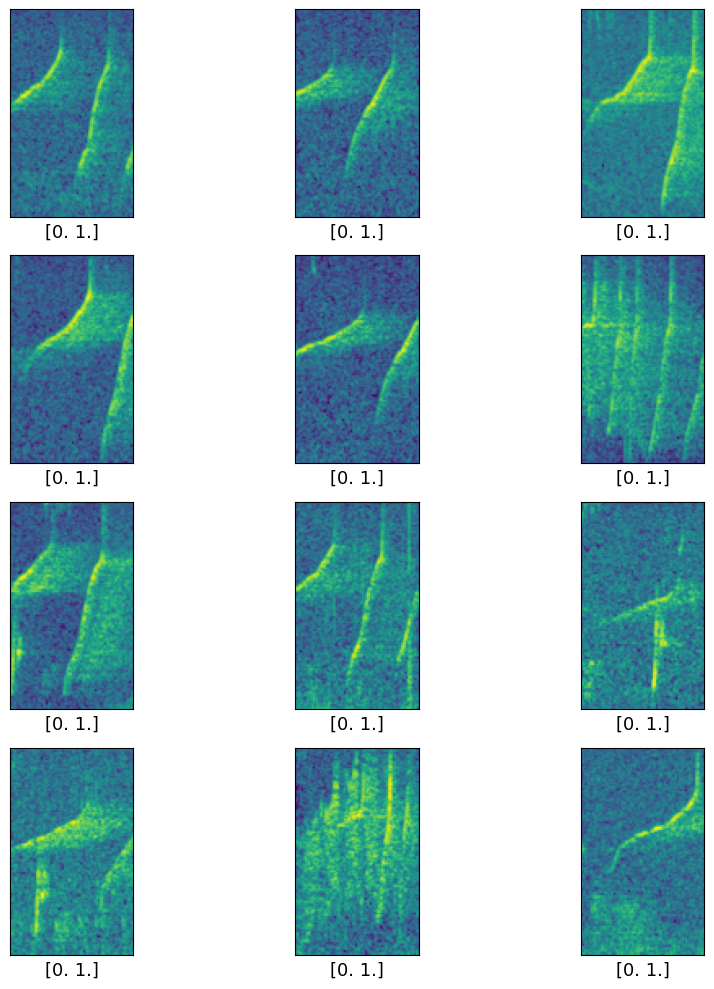

In [19]:
index_p=np.random.choice(index_positive, size=12, replace=False)

fig = plt.figure(figsize=(10,10))
w=0
for i in index_p:
    plt.subplot(4,3,w+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X[i],  origin='lower')
    plt.xlabel(Y[i], fontsize=13)
    w+=1
plt.tight_layout()



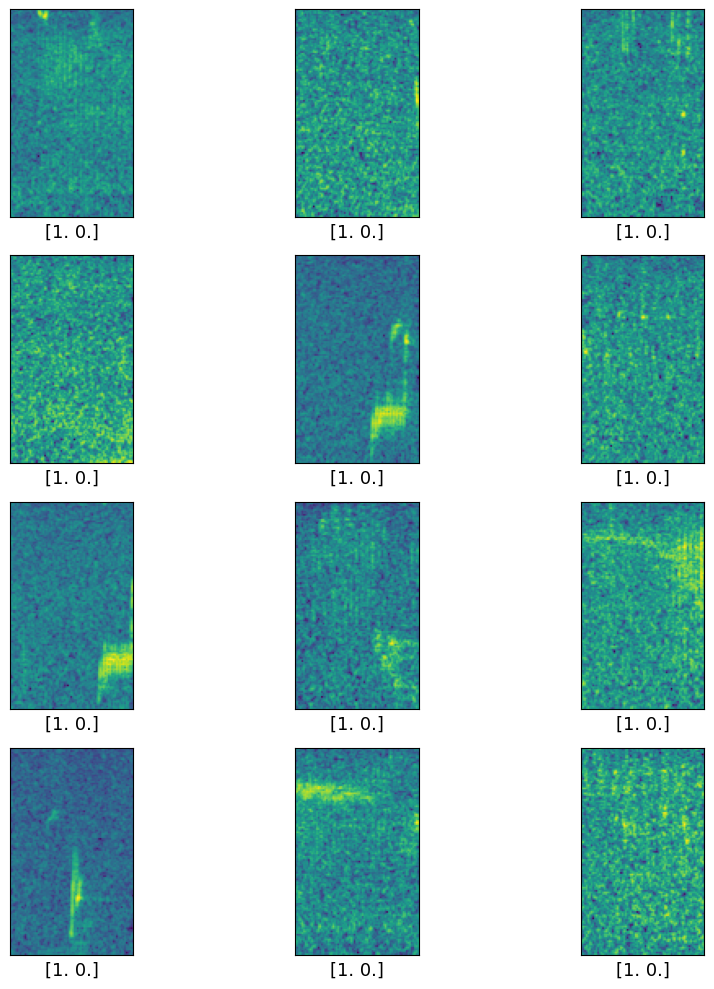

In [20]:

index_n=np.random.choice(index_negative, size=12, replace=False)
fig = plt.figure(figsize=(10,10))
w=0
for i in index_n:
    plt.subplot(4,3,w+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X[i],  origin='lower')
    plt.xlabel(Y[i], fontsize=13)
    w+=1
plt.tight_layout()